In [11]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import SGD
from sklearn.metrics import confusion_matrix, classification_report

In [15]:
base_path = "/content/drive/MyDrive/Colab Notebooks/AI and ML/Week 4 - Multi Layer Neural Network/DevanagariHandwrittenDigitDataset"

In [16]:
train_dir = base_path + "/Train"
test_dir = base_path + "/Test"

In [17]:
import os

print("Base exists:", os.path.exists(base_path))
print("Train exists:", os.path.exists(train_dir))
print("Test exists:", os.path.exists(test_dir))
print("Train folders:", os.listdir(train_dir))
print("Test folders:", os.listdir(test_dir))

Base exists: True
Train exists: True
Test exists: True
Train folders: ['digit_7', 'digit_2', 'digit_8', 'digit_3', 'digit_4', 'digit_5', 'digit_1', 'digit_9', 'digit_6', 'digit_0']
Test folders: ['digit_7', 'digit_9', 'digit_2', 'digit_3', 'digit_4', 'digit_1', 'digit_6', 'digit_8', 'digit_0', 'digit_5']


 3 · Load and Explore the Dataset

In [18]:

# 5.1. Function to get image paths and labels (Iterating and Reading)
def get_image_paths_and_labels(data_dir):
    image_paths = []
    labels = []

    # Get all class folders and sort them
    class_folders = sorted(os.listdir(data_dir))

    for folder_name in class_folders:
        folder_path = os.path.join(data_dir, folder_name)

        # Skip if not a folder
        if not os.path.isdir(folder_path):
            continue

        # Extract label from folder name like digit_0 -> 0
        label = int(folder_name.split("_")[1])

        # Read all images inside this folder
        for file_name in os.listdir(folder_path):
            file_path = os.path.join(folder_path, file_name)
            image_paths.append(file_path)
            labels.append(label)

    return image_paths, labels

print("Defined function: get_image_paths_and_labels")

Defined function: get_image_paths_and_labels


In [19]:

# 5.2. Function to load and resize images (Reading & Resizing)
def load_and_resize_images(image_paths, img_size=(28, 28)):
    images = []
    for file_path in image_paths:
        img = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            print(f"Could not read: {file_path}")
            continue
        img = cv2.resize(img, img_size)
        images.append(img)
    return np.array(images)

print("Defined function: load_and_resize_images")

Defined function: load_and_resize_images


 Data Pre-processing

In [20]:

# 5.3. Function to normalize pixel values (Normalizing)
def normalize_images(images):
    return images / 255.0

print("Defined function: normalize_images")

Defined function: normalize_images


In [21]:

# 5.4. Function to flatten images (Flattening)

def flatten_images(images):
    # images will be (num_images, height, width)
    # We want to flatten to (num_images, height * width)
    return images.reshape(images.shape[0], -1)

print("Defined function: flatten_images")

Defined function: flatten_images


In [ ]:

# 6. LOAD TRAINING AND TESTING DATA - Step-by-Step


# Step 1: Get image paths and labels
print("Getting train image paths and labels...")
train_image_paths, y_train = get_image_paths_and_labels(train_dir)
print("Getting test image paths and labels...")
test_image_paths, y_test = get_image_paths_and_labels(test_dir)

# Step 2: Load and resize images
print("Loading and resizing train images...")
X_train_raw = load_and_resize_images(train_image_paths)
print("Loading and resizing test images...")
X_test_raw = load_and_resize_images(test_image_paths)

# Step 3: Normalize pixel values
print("Normalizing train images...")
X_train_normalized = normalize_images(X_train_raw)
print("Normalizing test images...")
X_test_normalized = normalize_images(X_test_raw)

# Step 4: Flatten images
print("Flattening train images...")
X_train = flatten_images(X_train_normalized)
print("Flattening test images...")
X_test = flatten_images(X_test_normalized)

# Convert labels to numpy arrays (if not already done in get_image_paths_and_labels)
y_train = np.array(y_train, dtype=np.int32)
y_test = np.array(y_test, dtype=np.int32)

print("\n--- Data Loading Complete ---")
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

Getting train image paths and labels...
Getting test image paths and labels...
Loading and resizing train images...


### Visualise sample training images

/tmp/ipykernel_420/865681873.py:25: UserWarning: Glyph 2406 (\N{DEVANAGARI DIGIT ZERO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_420/865681873.py:25: UserWarning: Matplotlib currently does not support Devanagari natively.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2406 (\N{DEVANAGARI DIGIT ZERO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Matplotlib currently does not support Devanagari natively.
  fig.canvas.print_figure(bytes_io, **kw)


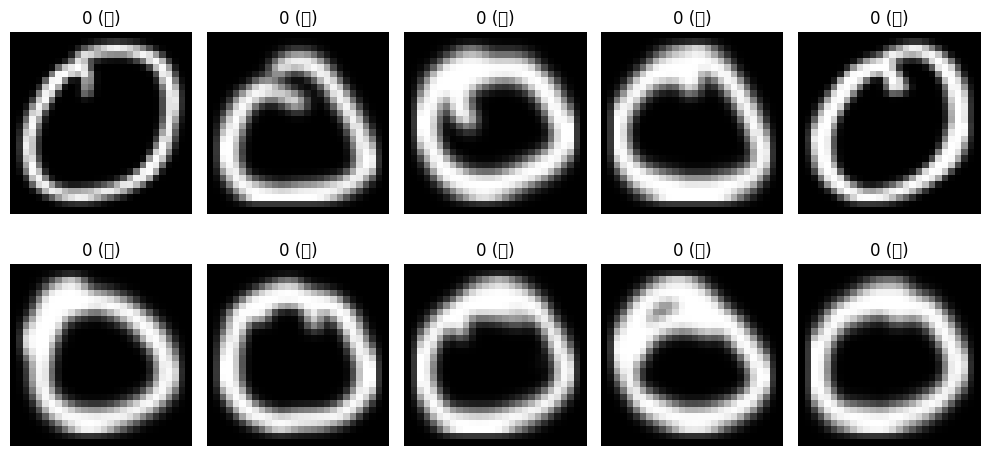

In [ ]:

# 7. DISPLAY SOME SAMPLE TRAINING IMAGES

nepali_digits = {
    0: "०",
    1: "१",
    2: "२",
    3: "३",
    4: "४",
    5: "५",
    6: "६",
    7: "७",
    8: "८",
    9: "९"
}

plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i].reshape(28, 28), cmap='gray')
    plt.title(f"{y_train[i]} ({nepali_digits[y_train[i]]})")
    plt.axis("off")

plt.tight_layout()
plt.show()

 Data Pre-processing

In [ ]:

# 8. ONE-HOT ENCODE LABELS


print("\nBefore encoding — sample labels:", y_train[4:10])
y_train = to_categorical(y_train, num_classes=10)
y_test  = to_categorical(y_test,  num_classes=10)
print("After encoding  — sample labels:\n", y_train[4:10])

print("\ny_train shape :", y_train.shape)
print("y_test  shape :", y_test.shape)


Before encoding — sample labels: [0 0 0 0 0 0]
After encoding  — sample labels:
 [[1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]

y_train shape : (17000, 10)
y_test  shape : (3000, 10)


## 5 · Define the Neural Network Architecture
###   Sequential API

In [ ]:
INPUT_SHAPE = (X_train.shape[1],)
NUM_CLASSES = y_train.shape[1]

seq_model = tf.keras.models.Sequential(
    [
        tf.keras.layers.Input(shape=INPUT_SHAPE),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(64,  activation="sigmoid"),
        tf.keras.layers.Dense(128, activation="sigmoid"),
        tf.keras.layers.Dense(256, activation="sigmoid"),
        tf.keras.layers.Dense(NUM_CLASSES, activation="softmax"),
    ],
    name="sequential_model"
)
seq_model.summary()

Model: "sequential_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

## 6 · Compile and Train

### Compilation settings

| Setting | Value | Rationale |
|---------|-------|-----------|
| Optimiser | Adam | Adaptive learning rate; works well out of the box |
| Loss | Categorical cross-entropy | Standard choice for multi-class, one-hot labels |
| Metric | Accuracy | Easy to interpret during training |

### Callbacks

* **EarlyStopping** — monitors validation loss and stops training if it fails
  to improve for `patience=5` consecutive epochs. `restore_best_weights=True`
  rolls back to the best checkpoint automatically.
* **ModelCheckpoint** — saves the model weights whenever the validation loss
  improves. Best practice: save only the best model, not every epoch.

### Validation split
15 % of the training data is held out as a validation set.  
The model **never trains on this data**; it is only used to monitor generalisation.


In [ ]:
# Compile
seq_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Callbacks
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath="best_model.keras",   # native Keras format (recommended)
        monitor="val_loss",
        save_best_only=True,
        verbose=0
    ),
]

BATCH_SIZE = 64
MAX_EPOCHS = 200

history = seq_model.fit(
    X_train, y_train,
    batch_size=BATCH_SIZE,
    epochs=MAX_EPOCHS,
    validation_split=0.15,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/200
226/226 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.5848 - loss: 1.2666 - val_accuracy: 0.1200 - val_loss: 5.3546
Epoch 2/200
226/226 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8707 - loss: 0.3722 - val_accuracy: 0.2278 - val_loss: 5.7033
Epoch 3/200
226/226 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9373 - loss: 0.2138 - val_accuracy: 0.2710 - val_loss: 5.9378
Epoch 4/200
226/226 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9595 - loss: 0.1419 - val_accuracy: 0.2827 - val_loss: 6.1354
Epoch 5/200
226/226 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9713 - loss: 0.1048 - val_accuracy: 0.2992 - val_loss: 6.3096
Epoch 6/200
226/226 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9780 - loss: 0.0802 - val_accuracy: 0.3141 - val_loss: 6.2621
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 1.


## 7 · Visualise Training History

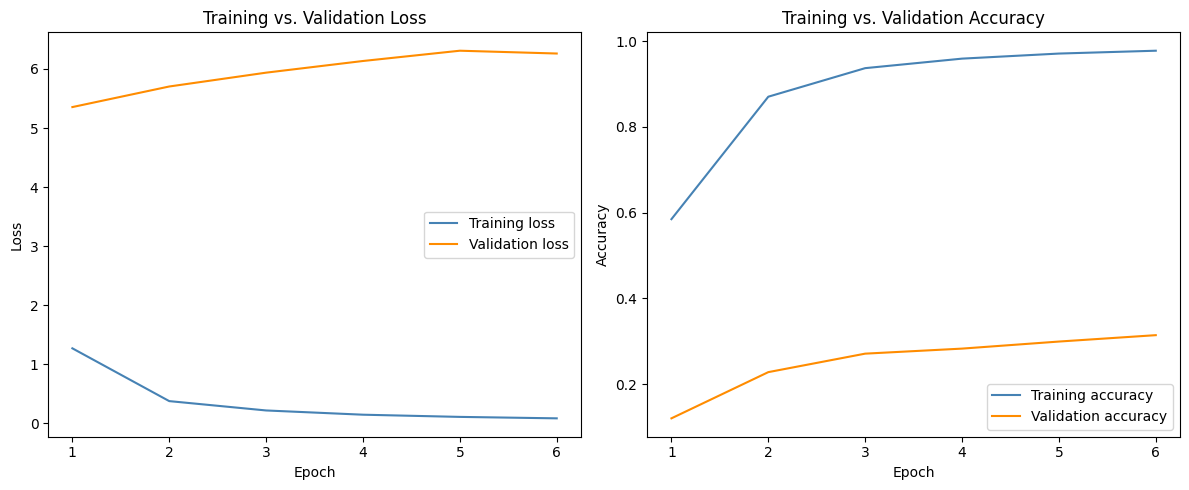

In [ ]:
import matplotlib.pyplot as plt

train_loss = history.history["loss"]
val_loss   = history.history["val_loss"]
train_acc  = history.history["accuracy"]
val_acc    = history.history["val_accuracy"]
epochs_ran = range(1, len(train_loss) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Loss
ax1.plot(epochs_ran, train_loss, color="steelblue",  label="Training loss")
ax1.plot(epochs_ran, val_loss,   color="darkorange", label="Validation loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Training vs. Validation Loss")
ax1.legend()

# Accuracy
ax2.plot(epochs_ran, train_acc, color="steelblue",  label="Training accuracy")
ax2.plot(epochs_ran, val_acc,   color="darkorange", label="Validation accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.set_title("Training vs. Validation Accuracy")
ax2.legend()

plt.tight_layout()
plt.show()


## 8 · Evaluate on the Test Set

In [ ]:
test_loss, test_acc = seq_model.evaluate(X_test, y_test, verbose=2)
print(f"\nTest loss     : {test_loss:.4f}")
print(f"Test accuracy : {test_acc:.4f}")

94/94 - 2s - 17ms/step - accuracy: 0.6973 - loss: 1.2572

Test loss     : 1.2572
Test accuracy : 0.6973


## 9 · Make Predictions and Inspect a Sample

94/94 - 1s - 6ms/step
Predicted label : 0
True label      : 0


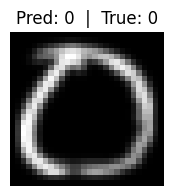

In [ ]:
# Get class probabilities for the entire test set
predictions = seq_model.predict(X_test, verbose=2)

# Convert probabilities → predicted class indices
predicted_labels = np.argmax(predictions, axis=1)

# Spot-check one sample (index 100)
SAMPLE_IDX = 12
print(f"Predicted label : {predicted_labels[SAMPLE_IDX]}")
print(f"True label      : {np.argmax(y_test[SAMPLE_IDX])}")

# Visualise the sample image
plt.figure(figsize=(2, 2))
plt.imshow(X_test[SAMPLE_IDX].reshape(28, 28), cmap="gray")
plt.title(f"Pred: {predicted_labels[SAMPLE_IDX]}  |  True: {np.argmax(y_test[SAMPLE_IDX])}")
plt.axis("off")
plt.show()


## 10 · Classification Metrics and Confusion Matrix

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Recall    : 0.6973
Precision : 0.6593
F1-score  : 0.6301


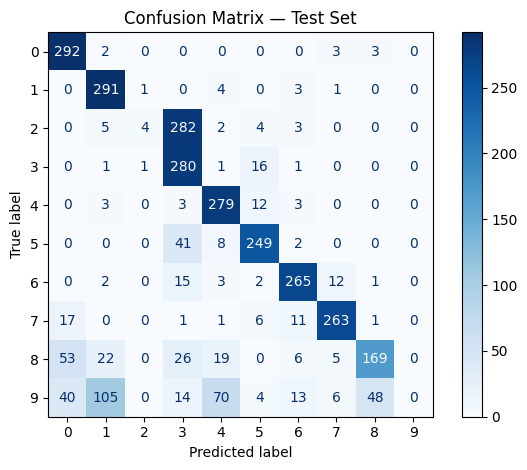

In [ ]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    recall_score,
    precision_score,
    f1_score,
)

# Ground-truth integer labels (undo one-hot encoding)
y_true = np.argmax(y_test, axis=1)

# Compute metrics
cm        = confusion_matrix(y_true, predicted_labels)
recall    = recall_score(y_true, predicted_labels, average="weighted")
precision = precision_score(y_true, predicted_labels, average="weighted")
f1        = f1_score(y_true, predicted_labels, average="weighted")

print(f"Recall    : {recall:.4f}")
print(f"Precision : {precision:.4f}")
print(f"F1-score  : {f1:.4f}")

# Plot confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=np.arange(10)
)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix — Test Set")
plt.tight_layout()
plt.show()
